IMPORTS

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb
import warnings
import pickle
import os

from scipy.signal import find_peaks

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error
)

from xgboost import XGBRegressor

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    LSTM,
    Dense,
    Dropout,
    BatchNormalization
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2

import shap

warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

CONFIGURATION

In [2]:
RECORDS = [
    '100',
    '101',
    '103',
    '105',
    '109',
    '111',
    '112',
    '113',
    '115',
    '117'
]

FS = 360
WINDOW_SIZE = 5
TEST_SIZE = 0.3
RANDOM_STATE = 42

print("Total records:", len(RECORDS))

Total records: 10


LOAD ECG RECORD

In [3]:
def load_ecg_record(record_id):

    try:

        record = wfdb.rdrecord(
            record_id,
            pn_dir='mitdb'
        )

        annotation = wfdb.rdann(
            record_id,
            'atr',
            pn_dir='mitdb'
        )

        return record, annotation

    except Exception as e:

        print("Error loading", record_id)
        print(e)

        return None, None

HEART RATE FUNCTIONS

In [4]:
def calculate_heart_rate(r_peaks, fs=360):

    rr_intervals = np.diff(r_peaks) / fs

    heart_rate = 60 / rr_intervals

    return heart_rate, rr_intervals


def remove_outliers_iqr(hr_series, threshold=3):

    Q1 = hr_series.quantile(0.25)
    Q3 = hr_series.quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR

    is_outlier = (
        (hr_series < lower_bound) |
        (hr_series > upper_bound)
    )

    hr_series_clean = hr_series.copy()

    hr_series_clean[is_outlier] = np.nan

    hr_series_clean = hr_series_clean.interpolate(
        method='linear',
        limit_direction='both'
    )

    return hr_series_clean


def smooth_signal(series, window=3):

    return series.rolling(
        window=window,
        center=True,
        min_periods=1
    ).mean()

PROCESS SINGLE RECORD

In [5]:
def process_single_record(record_id):

    print("Processing", record_id)

    record, annotation = load_ecg_record(record_id)

    if record is None:
        return None

    r_peaks = annotation.sample

    heart_rate, rr_intervals = calculate_heart_rate(
        r_peaks,
        FS
    )

    df = pd.DataFrame({
        'heart_rate': heart_rate
    })

    df.loc[
        (df['heart_rate'] < 40) |
        (df['heart_rate'] > 180),
        'heart_rate'
    ] = np.nan

    df['heart_rate'] = df['heart_rate'].interpolate(
        method='cubic',
        limit_direction='both'
    )

    df['heart_rate'] = remove_outliers_iqr(
        df['heart_rate']
    )

    df['heart_rate'] = smooth_signal(
        df['heart_rate'],
        window=3
    )

    df = df.dropna()

    print("Extracted", len(df), "HR values")

    return df['heart_rate'].values

PROCESS ALL RECORDS

In [6]:
all_hr_series = []

record_stats = []

for record_id in RECORDS:

    hr_values = process_single_record(record_id)

    if hr_values is not None:

        all_hr_series.append(hr_values)

        record_stats.append({
            'record': record_id,
            'n_samples': len(hr_values),
            'mean_hr': np.mean(hr_values),
            'std_hr': np.std(hr_values)
        })

all_hr = np.concatenate(all_hr_series)

print("Total HR samples:", len(all_hr))

Processing 100
Extracted 2273 HR values
Processing 101
Extracted 1873 HR values
Processing 103
Extracted 2090 HR values
Processing 105
Extracted 2690 HR values
Processing 109
Extracted 2534 HR values
Processing 111
Extracted 2132 HR values
Processing 112
Extracted 2549 HR values
Processing 113
Extracted 1795 HR values
Processing 115
Extracted 1961 HR values
Processing 117
Extracted 1538 HR values
Total HR samples: 21435


DATA VISUALIZATION

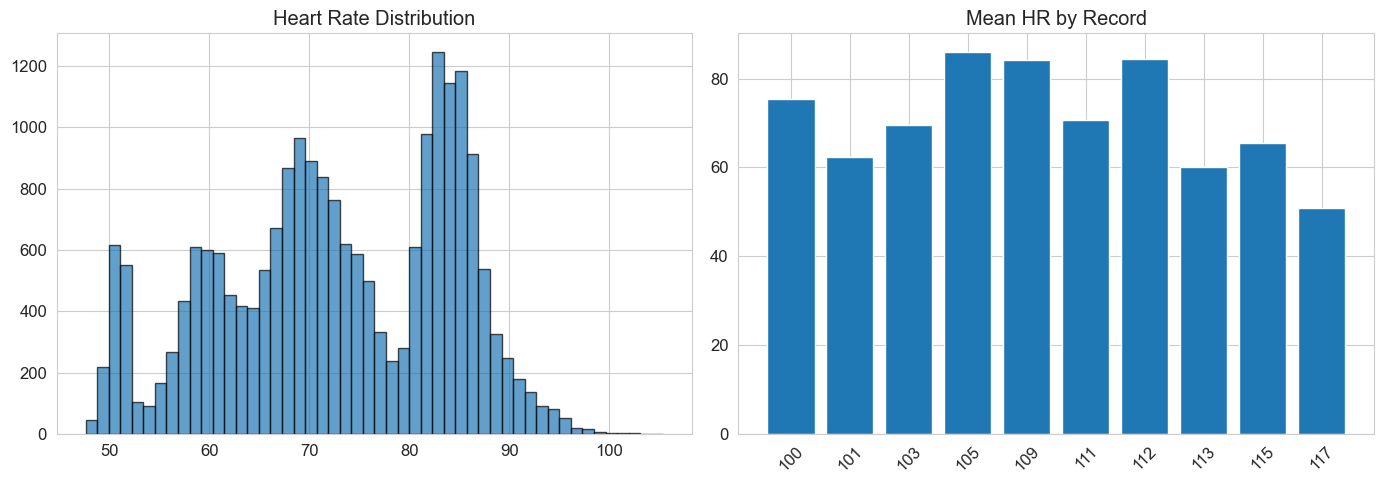

In [7]:
stats_df = pd.DataFrame(record_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(
    all_hr,
    bins=50,
    edgecolor='black',
    alpha=0.7
)

axes[0].set_title("Heart Rate Distribution")

axes[1].bar(
    stats_df['record'],
    stats_df['mean_hr']
)

axes[1].set_title("Mean HR by Record")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

FEATURE ENGINEERING

In [8]:
def create_advanced_features(
    hr_series,
    window_size=5
):

    X = []
    y = []

    for i in range(len(hr_series) - window_size):

        window = hr_series[i:i+window_size]

        mean_hr = np.mean(window)
        std_hr = np.std(window)

        min_hr = np.min(window)
        max_hr = np.max(window)

        slope, intercept = np.polyfit(
            range(window_size),
            window,
            1
        )

        rr_intervals = np.diff(window)

        rmssd = np.sqrt(
            np.mean(rr_intervals**2)
        )

        features = list(window) + [
            mean_hr,
            std_hr,
            min_hr,
            max_hr,
            slope,
            rmssd
        ]

        X.append(features)

        y.append(hr_series[i + window_size])

    return np.array(X), np.array(y)

CREATE FEATURES

In [9]:
X_raw, y_raw = create_advanced_features(
    all_hr,
    window_size=WINDOW_SIZE
)

print("Feature shape:", X_raw.shape)

Feature shape: (21430, 11)


DATA SCALING

In [10]:
feature_scaler = StandardScaler()

X_scaled = feature_scaler.fit_transform(X_raw)

target_scaler = StandardScaler()

y_scaled = target_scaler.fit_transform(
    y_raw.reshape(-1, 1)
).flatten()

TRAIN TEST SPLIT

In [11]:
train_size = int(
    len(X_scaled) * (1 - TEST_SIZE)
)

X_train = X_scaled[:train_size]
X_test = X_scaled[train_size:]

y_train = y_raw[:train_size]
y_test = y_raw[train_size:]

y_train_scaled = y_scaled[:train_size]
y_test_scaled = y_scaled[train_size:]

print("Train size:", len(X_train))
print("Test size:", len(X_test))

Train size: 15000
Test size: 6430


TIME SERIES CV

In [12]:
def time_series_cv(n_splits=3):

    return TimeSeriesSplit(
        n_splits=n_splits
    )

RANDOM FOREST

In [13]:
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10],
    'min_samples_split': [2, 5]
}

rf_model = RandomForestRegressor(
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_grid = GridSearchCV(
    rf_model,
    rf_param_grid,
    cv=time_series_cv(),
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_

print(rf_grid.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
{'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}


XGBOOST

In [14]:
xgb_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.01, 0.1]
}

xgb_model = XGBRegressor(
    random_state=RANDOM_STATE,
    verbosity=0,
    n_jobs=-1
)

xgb_grid = GridSearchCV(
    xgb_model,
    xgb_param_grid,
    cv=time_series_cv(),
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

best_xgb = xgb_grid.best_estimator_

print(xgb_grid.best_params_)

Fitting 3 folds for each of 8 candidates, totalling 24 fits
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}


PREPARE DEEP LEARNING DATA

In [15]:
X_train_dl = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test_dl = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print(X_train_dl.shape)

(15000, 11, 1)


CALLBACKS

In [16]:
callbacks = [

    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),

    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5
    ),

    ModelCheckpoint(
        'best_lstm.h5',
        save_best_only=True
    )
]

LSTM MODEL

In [17]:
def create_lstm_model(input_shape):

    model = Sequential([

        LSTM(
            64,
            return_sequences=True,
            input_shape=input_shape,
            kernel_regularizer=l2(0.001)
        ),

        BatchNormalization(),

        Dropout(0.3),

        LSTM(
            32,
            kernel_regularizer=l2(0.001)
        ),

        BatchNormalization(),

        Dropout(0.3),

        Dense(
            16,
            activation='relu'
        ),

        Dense(1)
    ])

    optimizer = Adam(
        learning_rate=0.001
    )

    model.compile(
        optimizer=optimizer,
        loss='mse',
        metrics=['mae']
    )

    return model

TRAIN LSTM

In [18]:
split_index = int(
    0.8 * len(X_train_dl)
)

X_train_dl_split = X_train_dl[:split_index]
X_val_dl = X_train_dl[split_index:]

y_train_dl_split = y_train_scaled[:split_index]
y_val_dl = y_train_scaled[split_index:]

lstm_model = create_lstm_model(
    (X_train_dl.shape[1], 1)
)

history = lstm_model.fit(

    X_train_dl_split,
    y_train_dl_split,

    validation_data=(
        X_val_dl,
        y_val_dl
    ),

    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/50
370/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7430 - mae: 0.5756

375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - loss: 0.4222 - mae: 0.4276 - val_loss: 0.2064 - val_mae: 0.3111 - learning_rate: 0.0010
Epoch 2/50
368/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2041 - mae: 0.2819

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1902 - mae: 0.2701 - val_loss: 0.1141 - val_mae: 0.1914 - learning_rate: 0.0010
Epoch 3/50
372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1573 - mae: 0.2411

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1544 - mae: 0.2420 - val_loss: 0.0856 - val_mae: 0.1571 - learning_rate: 0.0010
Epoch 4/50
373/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1373 - mae: 0.2323

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1320 - mae: 0.2278 - val_loss: 0.0668 - val_mae: 0.1320 - learning_rate: 0.0010
Epoch 5/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.1128 - mae: 0.2148 - val_loss: 0.0919 - val_mae: 0.2064 - learning_rate: 0.0010
Epoch 6/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1067 - mae: 0.2136

...

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0456 - mae: 0.1597 - val_loss: 0.0226 - val_mae: 0.1151 - learning_rate: 2.5000e-04
Epoch 28/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0435 - mae: 0.1545 - val_loss: 0.0243 - val_mae: 0.1220 - learning_rate: 2.5000e-04
Epoch 29/50
374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0416 - mae: 0.1507

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0418 - mae: 0.1514 - val_loss: 0.0175 - val_mae: 0.0933 - learning_rate: 2.5000e-04
Epoch 30/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0411 - mae: 0.1500 - val_loss: 0.0224 - val_mae: 0.1123 - learning_rate: 2.5000e-04
Epoch 31/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0391 - mae: 0.1449 - val_loss: 0.0190 - val_mae: 0.1022 - learning_rate: 2.5000e-04
Epoch 32/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0384 - mae: 0.1439 - val_loss: 0.0244 - val_mae: 0.1230 - learning_rate: 2.5000e-04
Epoch 33/50
372/375 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0365 - mae: 0.1413

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0370 - mae: 0.1409 - val_loss: 0.0172 - val_mae: 0.0958 - learning_rate: 2.5000e-04
Epoch 34/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0370 - mae: 0.1412 - val_loss: 0.0229 - val_mae: 0.1189 - learning_rate: 2.5000e-04
Epoch 35/50
374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0352 - mae: 0.1372

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0358 - mae: 0.1382 - val_loss: 0.0140 - val_mae: 0.0785 - learning_rate: 2.5000e-04
Epoch 36/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0356 - mae: 0.1374 - val_loss: 0.0153 - val_mae: 0.0885 - learning_rate: 2.5000e-04
Epoch 37/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0354 - mae: 0.1363 - val_loss: 0.0287 - val_mae: 0.1349 - learning_rate: 2.5000e-04
Epoch 38/50
374/375 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0342 - mae: 0.1337

375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0343 - mae: 0.1343 - val_loss: 0.0126 - val_mae: 0.0739 - learning_rate: 2.5000e-04
Epoch 39/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0343 - mae: 0.1332 - val_loss: 0.0129 - val_mae: 0.0769 - learning_rate: 2.5000e-04
Epoch 40/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0334 - mae: 0.1325 - val_loss: 0.0150 - val_mae: 0.0882 - learning_rate: 2.5000e-04
Epoch 41/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0329 - mae: 0.1315 - val_loss: 0.0179 - val_mae: 0.1014 - learning_rate: 2.5000e-04
Epoch 42/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0324 - mae: 0.1299 - val_loss: 0.0178 - val_mae: 0.0983 - learning_rate: 2.5000e-04
Epoch 43/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.0316 - mae: 0.1283 - val_loss: 0.0201 - val_mae: 0.1108 - learning_rate: 2.5000e-04
Epoch 44/50
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0302 - mae: 0.1246 - val_loss: 0.0135 - val_mae: 0.0779 - learning_

PREDICTIONS

In [21]:
rf_pred = best_rf.predict(X_test)

xgb_pred = best_xgb.predict(X_test)

lstm_pred_scaled = lstm_model.predict(
    X_test_dl
).flatten()

lstm_pred = target_scaler.inverse_transform(
    lstm_pred_scaled.reshape(-1, 1)
).flatten()

201/201 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


EVALUATION FUNCTION

In [22]:
def evaluate_model(
    y_true,
    y_pred,
    model_name
):

    mse = mean_squared_error(
        y_true,
        y_pred
    )

    rmse = np.sqrt(mse)

    mae = mean_absolute_error(
        y_true,
        y_pred
    )

    r2 = r2_score(
        y_true,
        y_pred
    )

    mape = (
        mean_absolute_percentage_error(
            y_true,
            y_pred
        ) * 100
    )

    print()
    print(model_name)

    print("RMSE:", rmse)
    print("MAE :", mae)
    print("MAPE:", mape)
    print("R2  :", r2)

    return {
        'model': model_name,
        'rmse': rmse,
        'mae': mae,
        'mape': mape,
        'r2': r2
    }

EVALUATE MODELS

In [23]:
results = []

results.append(
    evaluate_model(
        y_test,
        rf_pred,
        "Random Forest"
    )
)

results.append(
    evaluate_model(
        y_test,
        xgb_pred,
        "XGBoost"
    )
)

results.append(
    evaluate_model(
        y_test,
        lstm_pred,
        "LSTM"
    )
)

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    'rmse'
)

print(results_df)


Random Forest
RMSE: 3.0458999507554814
MAE : 2.271518682457401
MAPE: 4.046048498029208
R2  : 0.9244325055582978

XGBoost
RMSE: 3.5226591629836417
MAE : 2.5807747066349904
MAPE: 4.64150634074277
R2  : 0.8989247080229308

LSTM
RMSE: 3.9741349227020386
MAE : 2.991554948111855
MAPE: 5.39700353504269
R2  : 0.8713561675304184
           model      rmse       mae      mape        r2
0  Random Forest  3.045900  2.271519  4.046048  0.924433
1        XGBoost  3.522659  2.580775  4.641506  0.898925
2           LSTM  3.974135  2.991555  5.397004  0.871356


RESULTS VISUALIZATION

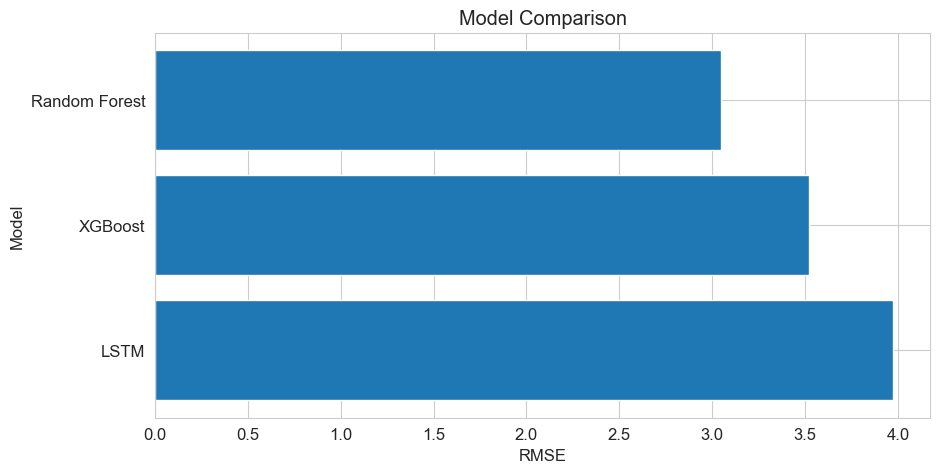

In [24]:
plt.figure(figsize=(10, 5))

plt.barh(
    results_df['model'],
    results_df['rmse']
)

plt.xlabel("RMSE")
plt.ylabel("Model")
plt.title("Model Comparison")

plt.gca().invert_yaxis()

plt.show()

BEST MODEL PREDICTION

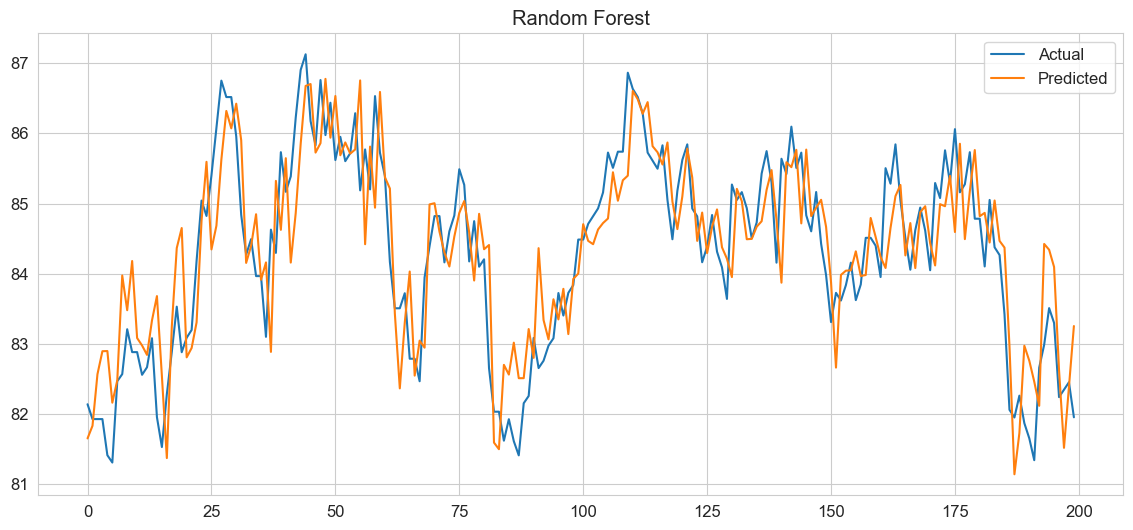

In [25]:
best_model_name = results_df.iloc[0]['model']

if best_model_name == "Random Forest":

    best_pred = rf_pred

elif best_model_name == "XGBoost":

    best_pred = xgb_pred

else:

    best_pred = lstm_pred

plt.figure(figsize=(14, 6))

plt.plot(
    y_test[:200],
    label='Actual'
)

plt.plot(
    best_pred[:200],
    label='Predicted'
)

plt.legend()

plt.title(best_model_name)

plt.show()

SHAP ANALYSIS

Best tree model: Random Forest


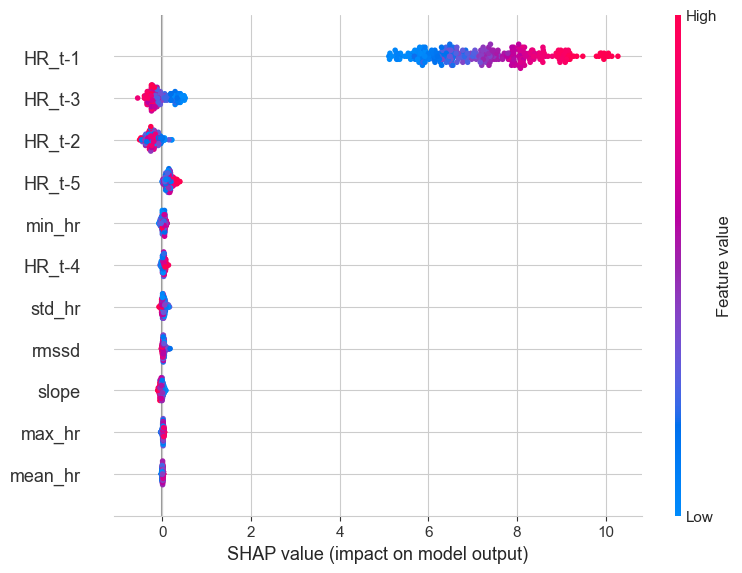

In [26]:
shap_models = [
    ('Random Forest', best_rf),
    ('XGBoost', best_xgb)
]

best_tree_model = None
best_tree_score = -np.inf

for name, model in shap_models:

    score = r2_score(
        y_test,
        model.predict(X_test)
    )

    if score > best_tree_score:

        best_tree_score = score

        best_tree_model = model

        best_tree_name = name

print("Best tree model:", best_tree_name)

explainer = shap.TreeExplainer(
    best_tree_model
)

shap_values = explainer.shap_values(
    X_test[:300]
)

feature_names = [
    'HR_t-5',
    'HR_t-4',
    'HR_t-3',
    'HR_t-2',
    'HR_t-1',
    'mean_hr',
    'std_hr',
    'min_hr',
    'max_hr',
    'slope',
    'rmssd'
]

shap.summary_plot(
    shap_values,
    X_test[:300],
    feature_names=feature_names
)

SAVE RESULTS

In [27]:
os.makedirs(
    'results',
    exist_ok=True
)

results_df.to_csv(
    'results/model_results.csv',
    index=False
)

with open(
    'results/best_rf.pkl',
    'wb'
) as f:

    pickle.dump(
        best_rf,
        f
    )

with open(
    'results/best_xgb.pkl',
    'wb'
) as f:

    pickle.dump(
        best_xgb,
        f
    )

with open(
    'results/feature_scaler.pkl',
    'wb'
) as f:

    pickle.dump(
        feature_scaler,
        f
    )

with open(
    'results/target_scaler.pkl',
    'wb'
) as f:

    pickle.dump(
        target_scaler,
        f
    )

print("Results saved")

Results saved
